In [1]:
import networkx as nx
import matplotlib.pyplot as plt
from cmcrameri import cm

In [2]:

# Create an empty graph
G = nx.Graph()
node_color = {}
colors = {}

# Add nodes and edges to the graph
with open("../input/s06/in.list.txt",'r') as f:
    in_ls = f.read().strip().split('\n')
    for i in in_ls:
        if i not in node_color.keys():
            G.add_node(i)
            node_color[i] = '#1EA01E' #'green'
            colors[node_color[i]] = f'Kept: {len(in_ls)} genotypes'
        else:
            raise ValueError(f"ERROR: {i} already in node_color")

with open("../input/s06/higher40_missing_rate_sample.list.txt",'r') as f:
    high_missing_ls = f.read().strip().split('\n')
    for i in high_missing_ls:
        if i not in node_color.keys():
            G.add_node(i)
            node_color[i] = '#999999'
            colors[node_color[i]] = f'Removed (SNP missing rate > 40%): {len(high_missing_ls)} genotypes'
        else:
            raise ValueError(f"ERROR: {i} already in node_color")

with open("../input/s06/remove_list_kinship0.354.txt",'r') as f:
    remove_kinship_ls = f.read().strip().split('\n')
    for i in remove_kinship_ls:
        if i not in node_color.keys():
            G.add_node(i)
            node_color[i] = '#666666' 
            colors[node_color[i]] = f'Removed (KING kinship > 0.354): {len(remove_kinship_ls)} genotypes'
        else:
            raise ValueError(f"ERROR: {i} already in node_color")

with open("../input/s06/remove_list_unclear_passport.txt", 'r') as f:
    remove_unclear_ls = f.read().strip().split('\n')
    for i in remove_unclear_ls:
        if i not in node_color.keys():
            G.add_node(i)
            node_color[i] = '#333333'
            colors[node_color[i]] = f'Removed (unclear passport information): {len(remove_unclear_ls)} genotypes'
        else:
            raise ValueError(f"ERROR: {i} already in node_color")

kinship_ls = list()
with open("../input/s06/without_clone0.354.kin0",'r') as f:
    fs = f.read().strip().split('\n')
    header, content = fs[0], fs[1:]
    header = header.strip("#").split()
    id1,id2 = header.index("ID1"), header.index("ID2")
    for i in content:
        i = i.split('\t')
        ind1 = i[id1]
        ind2 = i[id2]
        kinship = float(i[-1])
        if kinship >= 0.354:
            if (ind1 not in node_color) or (ind2 not in node_color):
                raise ValueError(f"ERROR: {i} not in node_color")
            G.add_edge(ind1,ind2,weight=kinship)


# Extract edge weights from the graph
edge_weights = [data['weight'] for _, _, data in G.edges(data=True)]


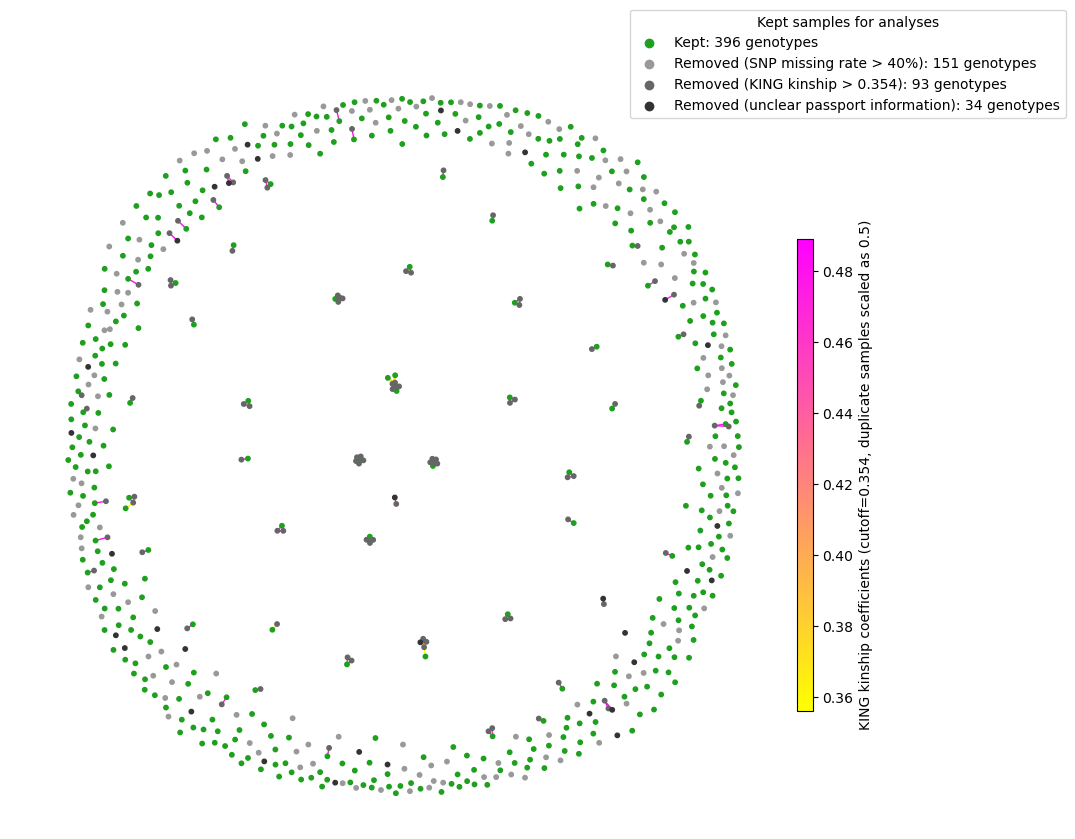

In [3]:

# Define the colormap for the edge color
cmap = plt.cm.spring_r  # You can choose any other colormap from `matplotlib.cm`
# cmap = cm.batlow

# Set the figure size
plt.figure(figsize=(7.87, 7.87))  # Change the width and height as needed

# Draw the graph using Matplotlib with custom node colors and edge colors
pos = nx.spring_layout(G, seed=4)  # Positions nodes using the spring layout algorithm
nx.draw(G, pos,
        with_labels=False, 
        node_color=[node_color[node] for node in G.nodes()], 
        #alpha=0.8,
        node_size=10, 
        font_size=10, 
        edge_color=edge_weights, 
        edge_cmap=cmap, 
        width=1)

# Create a legend for nodes only
for color, node in colors.items():
    plt.scatter([], [], c=[color], label=node)

# Display the legend
plt.legend(title="Kept samples for analyses", 
           loc="upper right", bbox_to_anchor=(1.35, 1.05))

# # Create a colorbar to show the edge value map
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=min(edge_weights), vmax=max(edge_weights)))
# You can specify the Axes to use for the colorbar using the cax argument
cax = plt.axes([1, 0.15, 0.02, 0.6])  # This sets the position of the colorbar relative to the plot
plt.colorbar(sm, cax=cax, label="KING kinship coefficients (cutoff=0.354, duplicate samples scaled as 0.5)")

# Display the plot
plt.savefig("../output/s06.samples_choosing_and_kinship.2024-08-13.png", format="png", bbox_inches="tight")
plt.show()